In [93]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math as mm
import opstool as opst
import time as tt

In [94]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [95]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to C:\Users\Michael 
Ocampo\Documents\mini\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [96]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (100144002347)>


In [97]:
##################################################################
#                                                                #
# Effective stress site response analysis for a layered          #
# soil profile located on a 2% slope and underlain by an         #
# elastic half-space.  9-node quadUP elements are used.          #
# The finite rigidity of the elastic half space is               #
# considered through the use of a viscous damper at the          #
# base.                                                          #
#                                                                #
#    Converted to openseespy by: Harsh Mistry                    #
#                                The University of Manchester    #
#                                                                #
#   Created by:  Chris McGann                                    #
#                HyungSuk Shin                                   #
#                Pedro Arduino                                   #
#                Peter Mackenzie-Helnwein                        #
#              --University of Washington--                      #
#                                                                #
# ---> Basic units are kN and m   (unless specified)             #
#                                                                #
##################################################################
#-----------------------------------------------------------------------------------------
#  1. DEFINE SOIL AND MESH GEOMETRY
#-----------------------------------------------------------------------------------------

ops.wipe()
nodes_dict = dict()

#---SOIL GEOMETRY
# thicknesses of soil profile (m)
soilThick = 30.0
# number of soil layers
numLayers = 3
# layer thicknesses
layerThick=[20.0,8.0,2.0]

# depth of water table
waterTable = 2.0

# define layer boundaries
layerBound=np.zeros((numLayers,1))
layerBound[0]=layerThick[0];
for i in range(1,numLayers):
    layerBound[i]=layerBound[i-1]+layerThick[i]
    
#---MESH GEOMETRY
# number of elements in horizontal direction
nElemX = 1
# number of nodes in horizontal direction
nNodeX =2 * nElemX+1
# horizontal element size (m)
sElemX = 2.0

# number of elements in vertical direction for each layer
nElemY = [40,16,4]

# total number of elements in vertical direction
nElemT = 60

sElemY = np.zeros((numLayers,1))
# vertical element size in each layer
for i in range(numLayers):
    sElemY[i] = [layerThick[i-1]/nElemY[i-1]]
    print('size:',sElemY[i])
    
# number of nodes in vertical direction
nNodeY = 2 * nElemT+1

# total number of nodes
nNodeT = nNodeX * nNodeY

#-----------------------------------------------------------------------------------------
#  2. CREATE PORE PRESSURE NODES AND FIXITIES
#-----------------------------------------------------------------------------------------
ops.model('basic', '-ndm', 2, '-ndf', 3) 

count = 1
layerNodeCount = 0
dry_Node=np.zeros((500,1))
node_save=np.zeros((500,1))
# loop over soil layers
for k in range(1,numLayers+1):
    # loop in horizontal direction
    for i in range(1,nNodeX+1,2):
       if k==1:
           bump = 1
       else:
           bump = 0
       j_end=2 * nElemY[k-1] + bump    
       for j in range(1,j_end+1,2):
            xCoord  = (i-1) * (sElemX/2)
            yctr    = j + layerNodeCount
            yCoord  = (yctr-1) * (float(sElemY[k-1]))/2
            nodeNum = i + ((yctr-1) * nNodeX)
            ops.node(nodeNum, xCoord, yCoord)

          # output nodal information to data file
            nodes_dict[nodeNum] = (nodeNum, xCoord, yCoord)
            node_save[nodeNum] = int(nodeNum)
          # designate nodes above water table
            waterHeight = soilThick - waterTable
            if yCoord >= waterHeight:
                dry_Node[count] = nodeNum
                count = count+1
    layerNodeCount = yctr + 1

dryNode=np.trim_zeros(dry_Node)
Node_d=np.unique(node_save)        
Node_d=np.trim_zeros(Node_d)
np.savetxt('Node_record.txt',Node_d)    
print('Finished creating all -ndf 3 nodes')
print('Number of Dry Nodes:',len(dryNode))    

# define fixities for pore pressure nodes above water table
for i in range(count-1):
    n_dryNode=int(dryNode[i])
    ops.fix(n_dryNode, 0, 0, 1)
    
ops.fix(1, 0, 1, 0)
ops.fix(3, 0, 1, 0)    
print('Finished creating all -ndf 3 boundary conditions...')

# define equal degrees of freedom for pore pressure nodes
for i in range(1,((3*nNodeY)-2),6):
    ops.equalDOF(i, i+2, 1, 2)
    
print("Finished creating equalDOF for pore pressure nodes...")

#-----------------------------------------------------------------------------------------
#  3. CREATE INTERIOR NODES AND FIXITIES
#-----------------------------------------------------------------------------------------
ops.model('basic', '-ndm', 2, '-ndf', 2) 

xCoord = float(sElemX/2)

# loop over soil layers
layerNodeCount = 0

for k in range(1,numLayers+1):
    if k==1:
        bump = 1
    else:
        bump = 0
    j_end=2 * nElemY[k-1] + bump    
    for j in range(1,j_end+1,1):
        yctr = j + layerNodeCount
        yCoord  = (yctr-1) * (float(sElemY[k-1]))/2
        nodeNum = (3*yctr) - 1 
        ops.node(nodeNum, xCoord, yCoord)
        # output nodal information to data file
        nodes_dict[nodeNum] = (nodeNum, xCoord, yCoord)
    
    layerNodeCount = yctr   

# interior nodes on the element edges
# loop over layers
layerNodeCount = 0

for k in range(1,numLayers+1):
    # loop in vertical direction
    for j in range(1,((nElemY[k-1])+1)):
        yctr     = j + layerNodeCount;
        yCoord   = float(sElemY[k-1])*(yctr-0.5)
        nodeNumL = (6*yctr) - 2
        nodeNumR = nodeNumL + 2
        
        ops.node(nodeNumL ,0.0, yCoord)
        ops.node(nodeNumR , sElemX, yCoord)
        
        # output nodal information to data file
        nodes_dict[nodeNumL] = (nodeNumL ,0.0, yCoord)
        nodes_dict[nodeNumR] = (nodeNumR , sElemX, yCoord)
    layerNodeCount = yctr

print("Finished creating all -ndf 2 nodes...")        

# define fixities for interior nodes at base of soil column
ops.fix(2, 0, 1)
print('Finished creating all -ndf 2 boundary conditions...')

# define equal degrees of freedom which have not yet been defined
for i in range(1,((3*nNodeY)-6),6):
    ops.equalDOF(i  , i+1, 1, 2)
    ops.equalDOF(i+3, i+4, 1, 2)
    ops.equalDOF(i+3, i+5, 1, 2)

ops.equalDOF(nNodeT-2, nNodeT-1, 1, 2)
print('Finished creating equalDOF constraints...')

#-----------------------------------------------------------------------------------------
#  4. CREATE SOIL MATERIALS
#-----------------------------------------------------------------------------------------

# define grade of slope (%)
grade = 2.0
slope = mm.atan(grade/100.0)
g     = -9.81

xwgt_var = g * (mm.sin(slope))
ywgt_var = g * (mm.cos(slope))
thick = [1.0,1.0,1.0]
xWgt  = [xwgt_var, xwgt_var, xwgt_var] 
yWgt  = [ywgt_var, ywgt_var, ywgt_var] 
uBulk = [6.88E6,  5.06E6, 5.0E-6]
hPerm = [1.0E-4, 1.0E-4, 1.0E-4]
vPerm = [1.0E-4, 1.0E-4, 1.0E-4]


# nDMaterial PressureDependMultiYield02
# nDMaterial('PressureDependMultiYield02', matTag, nd, rho, refShearModul, refBulkModul,\
#    frictionAng, peakShearStra, refPress, pressDependCoe, PTAng,\
#        contrac[0], contrac[2], dilat[0], dilat[2], noYieldSurf=20.0,\
#            *yieldSurf=[], contrac[1]=5.0, dilat[1]=3.0, *liquefac=[1.0,0.0],e=0.6, \
#                *params=[0.9, 0.02, 0.7, 101.0], c=0.1)

ops.nDMaterial('PressureDependMultiYield02',3, 2, 1.8, 9.0e4, 2.2e5, 32, 0.1, \
                                      101.0, 0.5, 26, 0.067, 0.23, 0.06, \
                                      0.27, 20, 5.0, 3.0, 1.0, \
                                      0.0, 0.77, 0.9, 0.02, 0.7, 101.0)

ops.nDMaterial('PressureDependMultiYield02', 2, 2, 2.24, 9.0e4, 2.2e5, 32, 0.1, \
                                      101.0, 0.5, 26, 0.067, 0.23, 0.06, \
                                      0.27, 20, 5.0, 3.0, 1.0, \
                                      0.0, 0.77, 0.9, 0.02, 0.7, 101.0)
    
ops.nDMaterial('PressureDependMultiYield02',1, 2, 2.45, 1.3e5, 2.6e5, 39, 0.1, \
                                      101.0, 0.5, 26, 0.010, 0.0, 0.35, \
                                      0.0, 20, 5.0, 3.0, 1.0, \
                                      0.0, 0.47, 0.9, 0.02, 0.7, 101.0)    

print("Finished creating all soil materials...")

#-----------------------------------------------------------------------------------------
#  5. CREATE SOIL ELEMENTS
#-----------------------------------------------------------------------------------------

for j in range(1,nElemT+1):
    nI = ( 6*j) - 5
    nJ = nI + 2
    nK = nI + 8
    nL = nI + 6
    nM = nI + 1
    nN = nI + 5
    nP = nI + 7
    nQ = nI + 3
    nR = nI + 4
    
    lowerBound = 0.0
    for i in range(1,numLayers+1):
        if j * sElemY[i-1] <= layerBound[i-1] and j * sElemY[i-1] > lowerBound:
            # permeabilities are initially set at 1.0 m/s for gravity analysis,
            ops.element('9_4_QuadUP', j, nI, nJ, nK, nL, nM, nN, nP, nQ, nR, \
                           thick[i-1], i, uBulk[i-1], 1.0, 1.0, 1.0, xWgt[i-1], yWgt[i-1])
                
        lowerBound = layerBound[i-1]
            
print("Finished creating all soil elements...")
#-----------------------------------------------------------------------------------------
#  6. LYSMER DASHPOT
#-----------------------------------------------------------------------------------------

# define dashpot nodes
dashF =  nNodeT+1
dashS =  nNodeT+2

ops.node(dashF,  0.0, 0.0)
ops.node(dashS,  0.0, 0.0)

# define fixities for dashpot nodes
ops.fix(dashF, 1, 1)
ops.fix(dashS, 0, 1)

# define equal DOF for dashpot and base soil node
ops.equalDOF(1, dashS,  1)
print('Finished creating dashpot nodes and boundary conditions...')

# define dashpot material
colArea      = sElemX * thick[0]
rockVS       = 700.0
rockDen      = 2.5
dashpotCoeff = rockVS * rockDen

#uniaxialMaterial('Viscous', matTag, C, alpha)
ops.uniaxialMaterial('Viscous', numLayers+1, dashpotCoeff * colArea, 1)

# define dashpot element
ops.element('zeroLength', nElemT+1, dashF, dashS, '-mat', numLayers+1, '-dir', 1)

print("Finished creating dashpot material and element...")

#-----------------------------------------------------------------------------------------
#  7. CREATE GRAVITY RECORDERS
#-----------------------------------------------------------------------------------------

# create list for pore pressure nodes
load_nodeList3=np.loadtxt('Node_record.txt')
nodeList3=[]

for i in range(len(load_nodeList3)):
    nodeList3.append(int(load_nodeList3[i]))
# record nodal displacment, acceleration, and porepressure
ops.recorder('Node','-file','Gdisplacement.txt','-time','-node',*nodeList3,'-dof', 1, 2, 'disp')
ops.recorder('Node','-file','Gacceleration.txt','-time','-node',*nodeList3,'-dof', 1, 2, 'accel')
ops.recorder('Node','-file','GporePressure.txt','-time','-node',*nodeList3,'-dof', 3, 'vel')

# record elemental stress and strain (files are names to reflect GiD gp numbering)
ops.recorder('Element','-file','Gstress1.txt','-time','-eleRange', 1,nElemT,'material','1','stress')
ops.recorder('Element','-file','Gstress2.txt','-time','-eleRange', 1,nElemT,'material','2','stress')
ops.recorder('Element','-file','Gstress3.txt','-time','-eleRange', 1,nElemT,'material','3','stress')
ops.recorder('Element','-file','Gstress4.txt','-time','-eleRange', 1,nElemT,'material','4','stress')
ops.recorder('Element','-file','Gstress9.txt','-time','-eleRange', 1,nElemT,'material','9','stress')
ops.recorder('Element','-file','Gstrain1.txt','-time','-eleRange', 1,nElemT,'material','1','strain')
ops.recorder('Element','-file','Gstrain2.txt','-time','-eleRange', 1,nElemT,'material','2','strain')
ops.recorder('Element','-file','Gstrain3.txt','-time','-eleRange', 1,nElemT,'material','3','strain')
ops.recorder('Element','-file','Gstrain4.txt','-time','-eleRange', 1,nElemT,'material','4','strain')
ops.recorder('Element','-file','Gstrain9.txt','-time','-eleRange', 1,nElemT,'material','9','strain')

print("Finished creating gravity recorders...")

#-----------------------------------------------------------------------------------------
#  8. DEFINE ANALYSIS PARAMETERS
#-----------------------------------------------------------------------------------------

#---GROUND MOTION PARAMETERS
# time step in ground motion record
motionDT = 0.005
# number of steps in ground motion record
motionSteps = 7990

#---RAYLEIGH DAMPING PARAMETERS
# damping ratio
damp = 0.02
# lower frequency
omega1 = 2 * np.pi * 0.2
# upper frequency
omega2 = 2 * np.pi * 20
# damping coefficients
a0 = 2*damp*omega1*omega2/(omega1 + omega2)
a1 = 2*damp/(omega1 + omega2)
print("Damping Coefficients: a_0 = $a0;  a_1 = $a1")

#---DETERMINE STABLE ANALYSIS TIME STEP USING CFL CONDITION
# maximum shear wave velocity (m/s)
vsMax = 250.0
# duration of ground motion (s)
duration = motionDT*motionSteps
# minimum element size
minSize = sElemY[0]

for i in range(2,numLayers+1):
    if sElemY[i-1] <= minSize:
        minSize = sElemY[i-1]

# trial analysis time step
kTrial = minSize/(vsMax**0.5)
# define time step and number of steps for analysis
if motionDT <= kTrial:
    nSteps = motionSteps
    dT     = motionDT
else:
    nSteps = np.int(mm.floor(duration/kTrial)+1)
    dT     = duration/nSteps
    

print("Number of steps in analysis: $nSteps")
print("Analysis time step: $dT")

#---ANALYSIS PARAMETERS
# Newmark parameters
gamma = 0.5
beta  = 0.25

#-----------------------------------------------------------------------------------------
#  9. GRAVITY ANALYSIS
#-----------------------------------------------------------------------------------------
# update materials to ensure elastic behavior
ops.updateMaterialStage('-material', 1, '-stage', 0)
ops.updateMaterialStage('-material', 2, '-stage', 0)
ops.updateMaterialStage('-material', 3, '-stage', 0)

ops.constraints('Penalty', 1.0E14, 1.0E14)
ops.test('NormDispIncr', 1e-4, 35, 1)
ops.algorithm('KrylovNewton')
ops.numberer('RCM')
ops.system('ProfileSPD')
ops.integrator('Newmark', gamma, beta)
ops.analysis('Transient')

startT = tt.time()
ops.analyze(10, 5.0E2)
print('Finished with elastic gravity analysis...')

# update material to consider elastoplastic behavior
ops.updateMaterialStage('-material', 1, '-stage', 1)
ops.updateMaterialStage('-material', 2, '-stage', 1)
ops.updateMaterialStage('-material', 3, '-stage', 1)

# plastic gravity loading
ops.analyze(40, 5.0e2)

print('Finished with plastic gravity analysis...')

#-----------------------------------------------------------------------------------------
#  10. UPDATE ELEMENT PERMEABILITY VALUES FOR POST-GRAVITY ANALYSIS
#-----------------------------------------------------------------------------------------

# choose base number for parameter IDs which is higer than other tags used in analysis
ctr = 10000.0
# loop over elements to define parameter IDs 
for i in range(1,nElemT+1):
    ops.parameter(int(ctr+1.0), 'element', i, 'vPerm')
    ops.parameter(int(ctr+2.0), 'element', i, 'hPerm')
    ctr   = ctr+2.0

# update permeability parameters for each element using parameter IDs
ctr = 10000.0
for j in range(1,nElemT+1):
    lowerBound = 0.0
    for i in range(1,numLayers+1):
        if j * sElemY[i-1] <= layerBound[i-1] and j*sElemY[i-1] > lowerBound:
            ops.updateParameter(int(ctr+1.0), vPerm[i-1])
            ops.updateParameter(int(ctr+2.0), hPerm[i-1])
        lowerBound = layerBound[i-1]
    ctr = ctr+2.0

print("Finished updating permeabilities for dynamic analysis...")

#-----------------------------------------------------------------------------------------
#  11. CREATE POST-GRAVITY RECORDERS
#-----------------------------------------------------------------------------------------

# reset time and analysis
ops.setTime(0.0)
ops.wipeAnalysis()
ops.remove('recorders')

# recorder time step
recDT = 10*motionDT

# record nodal displacment, acceleration, and porepressure
ops.recorder('Node','-file','displacement.txt','-time', '-dT',recDT,'-node',*nodeList3,'-dof', 1, 2, 'disp')
ops.recorder('Node','-file','acceleration.txt','-time', '-dT',recDT,'-node',*nodeList3,'-dof', 1, 2, 'accel')
ops.recorder('Node','-file','porePressure.txt','-time', '-dT',recDT,'-node',*nodeList3,'-dof', 3, 'vel')

# record elemental stress and strain (files are names to reflect GiD gp numbering)
ops.recorder('Element','-file','stress1.txt','-time', '-dT',recDT,'-eleRange', 1,nElemT,'material','1','stress')
ops.recorder('Element','-file','stress2.txt','-time', '-dT',recDT,'-eleRange', 1,nElemT,'material','2','stress')
ops.recorder('Element','-file','stress3.txt','-time', '-dT',recDT,'-eleRange', 1,nElemT,'material','3','stress')
ops.recorder('Element','-file','stress4.txt','-time', '-dT',recDT,'-eleRange', 1,nElemT,'material','4','stress')
ops.recorder('Element','-file','stress9.txt','-time', '-dT',recDT,'-eleRange', 1,nElemT,'material','9','stress')
ops.recorder('Element','-file','strain1.txt','-time', '-dT',recDT,'-eleRange', 1,nElemT,'material','1','strain')
ops.recorder('Element','-file','strain2.txt','-time', '-dT',recDT,'-eleRange', 1,nElemT,'material','2','strain')
ops.recorder('Element','-file','strain3.txt','-time', '-dT',recDT,'-eleRange', 1,nElemT,'material','3','strain')
ops.recorder('Element','-file','strain4.txt','-time', '-dT',recDT,'-eleRange', 1,nElemT,'material','4','strain')
ops.recorder('Element','-file','strain9.txt','-time', '-dT',recDT,'-eleRange', 1,nElemT,'material','9','strain')

print("Finished creating all recorders...")

#-----------------------------------------------------------------------------------------
#  12. DYNAMIC ANALYSIS
#-----------------------------------------------------------------------------------------
ops.model('basic', '-ndm', 2, '-ndf', 3)

# define constant scaling factor for applied velocity
cFactor = colArea * dashpotCoeff

# define velocity time history file
velocityFile='velocityHistory';
data_gm=np.loadtxt('velocityHistory.txt')
#motionSteps=len(data_gm)
#print('Number of point for GM:',motionSteps)

# timeseries object for force history
ops.timeSeries('Path', 2, '-dt', motionDT, '-filePath', velocityFile+'.txt', '-factor', cFactor)
ops.pattern('Plain', 10, 2)
ops.load(1, 1.0, 0.0, 0.0)

print( "Dynamic loading created...")

ops.constraints('Penalty', 1.0E16, 1.0E16)
ops.test('NormDispIncr', 1e-3, 35, 1)
ops.algorithm('KrylovNewton')
ops.numberer('RCM')
ops.system('ProfileSPD')
ops.integrator('Newmark', gamma, beta)
ops.rayleigh(a0, a1, 0.0, 0.0)
ops.analysis('Transient')


size: [0.5]
size: [0.5]
size: [0.5]
Finished creating all -ndf 3 nodes
Number of Dry Nodes: 10
Finished creating all -ndf 3 boundary conditions...
Finished creating equalDOF for pore pressure nodes...
Finished creating all -ndf 2 nodes...
Finished creating all -ndf 2 boundary conditions...
Finished creating equalDOF constraints...
Finished creating all soil materials...
Finished creating all soil elements...
Finished creating dashpot nodes and boundary conditions...
Finished creating dashpot material and element...
Finished creating gravity recorders...
Damping Coefficients: a_0 = $a0;  a_1 = $a1
Number of steps in analysis: $nSteps
Analysis time step: $dT
Finished with elastic gravity analysis...


C:\Users\Michael Ocampo\AppData\Local\Temp\ipykernel_24688\3898426612.py:93: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\Michael Ocampo\AppData\Local\Temp\ipykernel_24688\3898426612.py:116: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\Michael Ocampo\AppData\Local\Temp\ipykernel_24688\3898426612.py:147: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\Michael Ocampo\AppData\Local\Temp\ipykernel_24688\3898426612.py:163: DeprecationWarning:


Finished with plastic gravity analysis...
Finished updating permeabilities for dynamic analysis...
Finished creating all recorders...
Dynamic loading created...


CTestNormDispIncr::test() - iteration: 1 current Norm: 850222 (max: 0.0001, Norm R: 28.8007)
CTestNormDispIncr::test() - iteration: 2 current Norm: 2.52575 (max: 0.0001, Norm R: 27.7807)
CTestNormDispIncr::test() - iteration: 3 current Norm: 0.0819721 (max: 0.0001, Norm R: 27.6359)
CTestNormDispIncr::test() - iteration: 4 current Norm: 0.000908349 (max: 0.0001, Norm R: 25.573)
CTestNormDispIncr::test() - iteration: 5 current Norm: 1.30935e-05 (max: 0.0001, Norm R: 26.3168)

CTestNormDispIncr::test() - iteration: 1 current Norm: 850222 (max: 0.0001, Norm R: 30.3046)
CTestNormDispIncr::test() - iteration: 2 current Norm: 2.50042 (max: 0.0001, Norm R: 27.8712)
CTestNormDispIncr::test() - iteration: 3 current Norm: 0.0858742 (max: 0.0001, Norm R: 28.2518)
CTestNormDispIncr::test() - iteration: 4 current Norm: 4.39416e-07 (max: 0.0001, Norm R: 27.564)

CTestNormDispIncr::test() - iteration: 1 current Norm: 850222 (max: 0.0001, Norm R: 36.4638)
CTestNormDispIncr::test() - iteration: 2 curren

In [98]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = False)

In [99]:
# Initialize ODB for response tracking
ODB = opst.post.CreateODB(
    odb_tag=1,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",  # "extrapolate", "copy", "average"
)
for _ in range(7990):
    ops.analyze(1, 0.005)
    ODB.fetch_response_step()
ODB.save_response(zlib=True)

CTestNormDispIncr::test() - iteration: 1 current Norm: 8.50117 (max: 0.001, Norm R: 2707.73)
CTestNormDispIncr::test() - iteration: 2 current Norm: 7.83209e-06 (max: 0.001, Norm R: 1797.64)

CTestNormDispIncr::test() - iteration: 1 current Norm: 8.49848 (max: 0.001, Norm R: 1877.45)
CTestNormDispIncr::test() - iteration: 2 current Norm: 4.55729e-07 (max: 0.001, Norm R: 1957.81)

CTestNormDispIncr::test() - iteration: 1 current Norm: 8.49575 (max: 0.001, Norm R: 2179.96)
CTestNormDispIncr::test() - iteration: 2 current Norm: 2.10018e-07 (max: 0.001, Norm R: 2105.99)

CTestNormDispIncr::test() - iteration: 1 current Norm: 8.49449 (max: 0.001, Norm R: 1894.15)
CTestNormDispIncr::test() - iteration: 2 current Norm: 7.56068e-08 (max: 0.001, Norm R: 2008.47)

CTestNormDispIncr::test() - iteration: 1 current Norm: 8.49486 (max: 0.001, Norm R: 1745.59)
CTestNormDispIncr::test() - iteration: 2 current Norm: 8.69372e-08 (max: 0.001, Norm R: 1862.98)

CTestNormDispIncr::test() - iteration: 1 curr

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

In [100]:
ele_resp = opst.post.get_element_responses(odb_tag=1, ele_type="Plane")
print("Data Variables in Element Responses:", ele_resp.data_vars)

OPSTOOL ::  Loading Plane response data from .opstool.output/RespStepData-1.nc ...

Data Variables in Element Responses: Data variables:
    Stresses               (time, eleTags, GaussPoints, stressDOFs) float32 86MB ...
    Strains                (time, eleTags, GaussPoints, strainDOFs) float32 52MB ...
    StressesAtNodes        (time, nodeTags, stressDOFs) float32 58MB -166.5 ....
    StrainsAtNodes         (time, nodeTags, strainDOFs) float32 35MB -4.405e-...
    StressAtNodesErr       (time, nodeTags, stressDOFs) float32 58MB 0.0 ... 0.0
    StrainsAtNodesErr      (time, nodeTags, strainDOFs) float32 35MB 0.0 ... 0.0
    StressMeasures         (time, eleTags, GaussPoints, measures) float32 69MB ...
    StrainMeasures         (time, eleTags, GaussPoints, measures) float32 69MB ...
    StressMeasuresAtNodes  (time, nodeTags, measures) float32 46MB -165.7 ......
    StrainMeasuresAtNodes  (time, nodeTags, measures) float32 46MB 1.161e-05 ...


In [101]:
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=15)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=15)
sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma33", eleTags=15)
sigma12 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=15)
eta_r = ele_resp["Stresses"].sel(stressDOFs="eta_r", eleTags=15)

In [102]:
po = (sigma11 + sigma22 + sigma33) / 3.0
qo = (sigma11 - sigma22) ** 2 + (sigma22 - sigma33) ** 2 + (sigma33 - sigma11) ** 2 + 6 * (sigma12**2)
qo = np.sign(sigma12) * 1 / 3 * np.sqrt(qo)
print(qo)

<xarray.DataArray 'Stresses' (time: 7991, GaussPoints: 9)> Size: 288kB
array([[-89.9775  , -89.9775  , -88.4122  , ..., -88.4122  , -89.19487 ,
        -89.19487 ],
       [-89.9751  , -89.9751  , -88.40988 , ..., -88.40988 , -89.19249 ,
        -89.19249 ],
       [-89.97302 , -89.97302 , -88.4078  , ..., -88.4078  , -89.190414,
        -89.190414],
       ...,
       [-33.498528, -33.498528, -33.065315, ..., -33.065315, -33.285236,
        -33.285236],
       [-33.49893 , -33.498924, -33.06571 , ..., -33.06571 , -33.28565 ,
        -33.28565 ],
       [-33.49935 , -33.49935 , -33.06612 , ..., -33.06612 , -33.286053,
        -33.286053]], shape=(7991, 9), dtype=float32)
Coordinates:
  * time         (time) float32 32kB 0.0 0.005 0.01 0.015 ... 39.94 39.94 39.95
    eleTags      int64 8B 15
  * GaussPoints  (GaussPoints) int64 72B 1 2 3 4 5 6 7 8 9
    stressDOFs   <U7 28B 'sigma12'


In [103]:
eps11 = ele_resp["Strains"].sel(strainDOFs="eps11", eleTags=15)
eps22 = ele_resp["Strains"].sel(strainDOFs="eps22", eleTags=15)
eps12 = ele_resp["Strains"].sel(strainDOFs="eps12", eleTags=15)

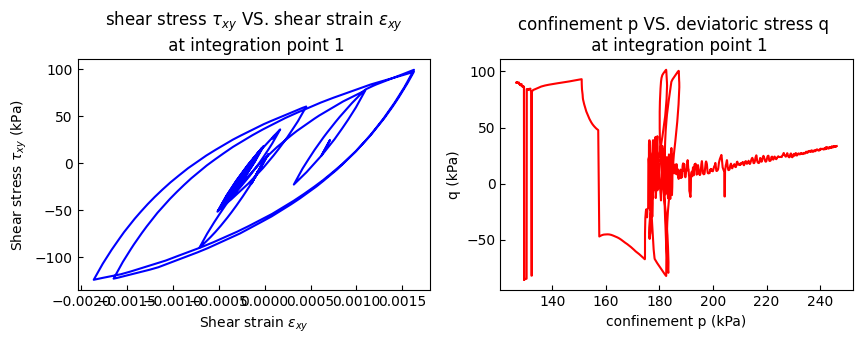

In [104]:
eps12_ele1_1 = eps12.sel(GaussPoints=1)
sigma12_ele1_1 = sigma12.sel(GaussPoints=1)
sigma11_ele1_1 = sigma11.sel(GaussPoints=1)
#po_ele1_1 = po.sel(GaussPoints=1)
qo_ele1_1 = qo.sel(GaussPoints=1)

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(eps12_ele1_1, sigma12_ele1_1, "b")
axs[0].set_title("shear stress $\\tau_{xy}$ VS. shear strain $\\epsilon_{xy}$ \n at integration point 1")
axs[0].set_xlabel(r"Shear strain $\epsilon_{xy}$")
axs[0].set_ylabel(r"Shear stress $\tau_{xy}$ (kPa)")
axs[1].plot(-sigma11_ele1_1, -qo_ele1_1, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("confinement p (kPa)")
axs[1].set_ylabel("q (kPa)")
plt.show()

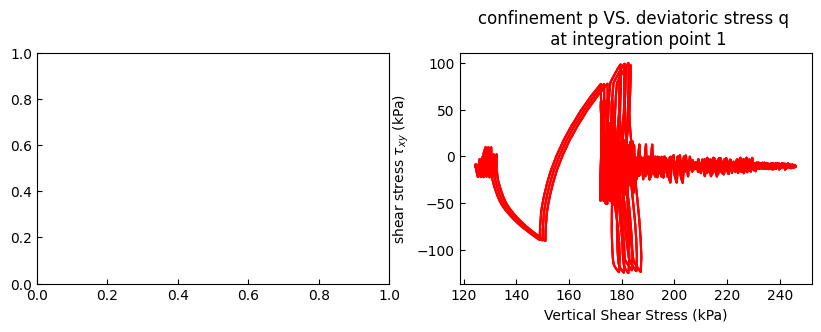

In [105]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[1].plot(-sigma11, sigma12, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("Vertical Shear Stress (kPa)")
axs[1].set_ylabel("shear stress $\\tau_{xy}$ (kPa)")
plt.show()

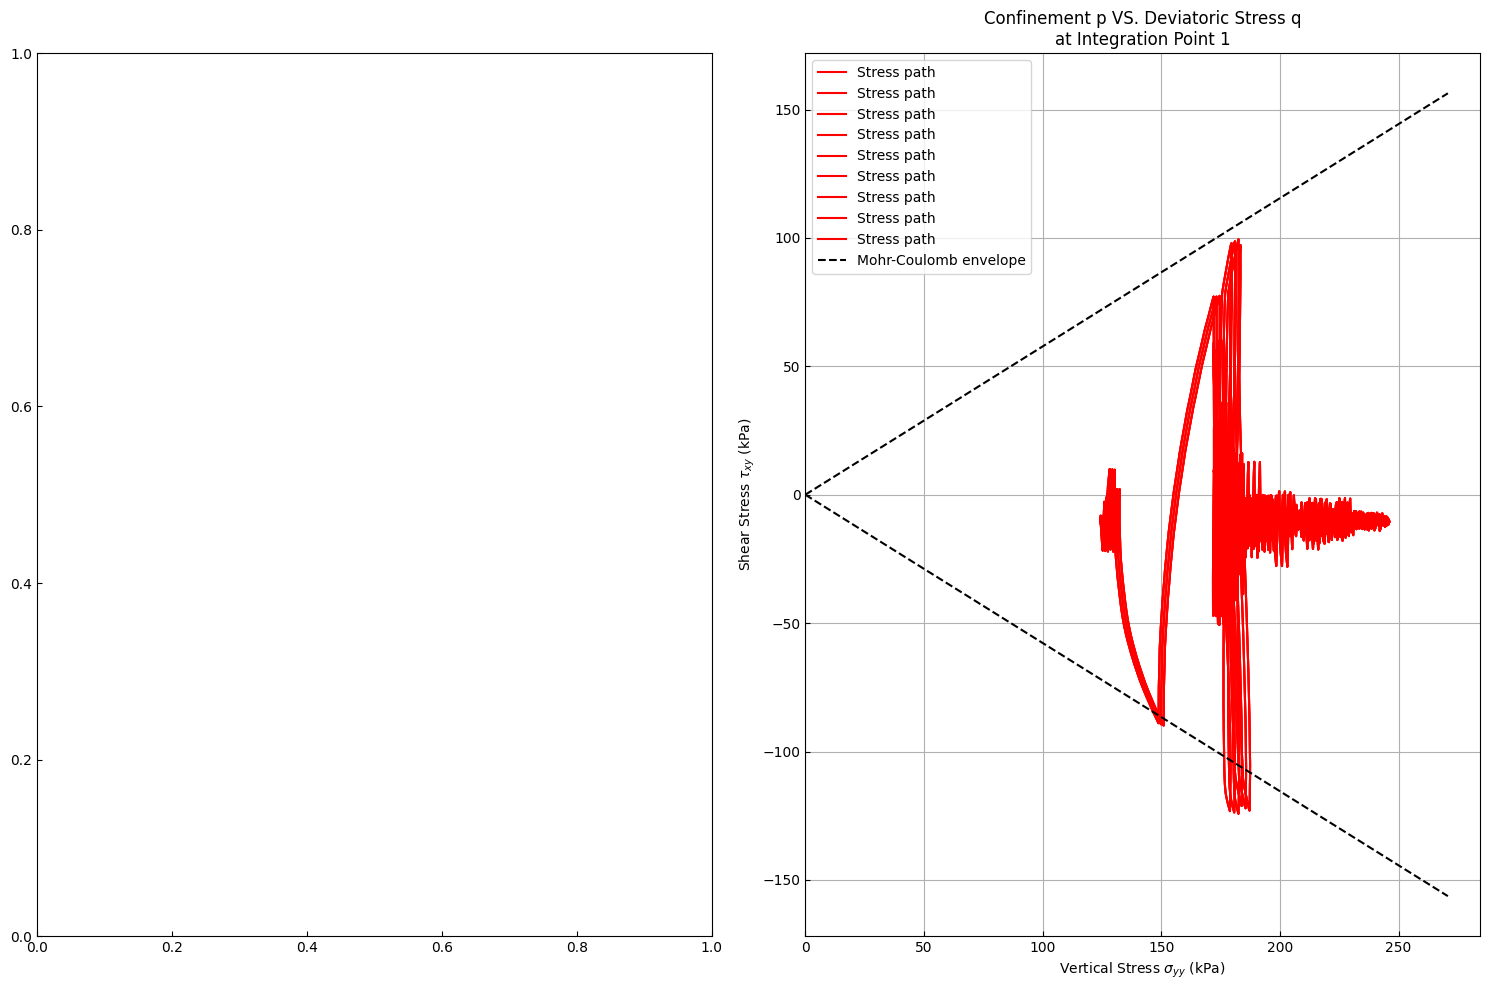

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# Inputs (example values; replace with your actual values)
phi_deg = 30
cohesion = 0
phi_rad = np.radians(phi_deg)

# Stress data (make sure these are NumPy arrays)
sigma11 = np.array(sigma11)  # Normal stress
sigma12 = np.array(sigma12)  # Shear stress

# Mohr-Coulomb envelope
sigma_range = np.linspace(0, np.max(-sigma11) * 1.1, 200)
tau_envelope = cohesion + sigma_range * np.tan(phi_rad)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(15, 10))

# Stress path
axs[1].plot(-sigma11, sigma12, "r", label="Stress path")

# Mohr-Coulomb lines
axs[1].plot(sigma_range, tau_envelope, "k--", label="Mohr-Coulomb envelope")
axs[1].plot(sigma_range, -tau_envelope, "k--")  # Mirror (negative shear)

# Styling
axs[1].set_title("Confinement p VS. Deviatoric Stress q\nat Integration Point 1")
axs[1].set_xlabel("Vertical Stress $\\sigma_{yy}$ (kPa)")
axs[1].set_ylabel("Shear Stress $\\tau_{xy}$ (kPa)")
axs[1].legend()
axs[1].grid(True)
axs[1].set_xlim(left=0)
axs[1].set_ylim(
    bottom=-1.1 * np.max(np.abs(tau_envelope)),
    top=1.1 * np.max(np.abs(tau_envelope))
)

plt.tight_layout()
plt.show()
